## ML&Fintech HW3 Ch4 Q9

Name: Alvin B. Lin\
Student ID: 112652040\
HW Number: 3\
Date: 13/10/2025

9. This question involves the use of multiple linear regression on the `Auto` data set.

(a) Produce a scatterplot matrix which includes all of the variables in the data set.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Auto.csv')
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  year  \
0  18.0          8         307.0        130    3504          12.0    70   
1  15.0          8         350.0        165    3693          11.5    70   
2  18.0          8         318.0        150    3436          11.0    70   
3  16.0          8         304.0        150    3433          12.0    70   
4  17.0          8         302.0        140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


---

(b) Compute the matrix of correlations between the variables using the `DataFrame.corr()` method.

                   mpg  cylinders  displacement    weight  acceleration  \
mpg           1.000000  -0.776260     -0.804443 -0.831739      0.422297   
cylinders    -0.776260   1.000000      0.950920  0.897017     -0.504061   
displacement -0.804443   0.950920      1.000000  0.933104     -0.544162   
weight       -0.831739   0.897017      0.933104  1.000000     -0.419502   
acceleration  0.422297  -0.504061     -0.544162 -0.419502      1.000000   
year          0.581469  -0.346717     -0.369804 -0.307900      0.282901   
origin        0.563698  -0.564972     -0.610664 -0.581265      0.210084   

                  year    origin  
mpg           0.581469  0.563698  
cylinders    -0.346717 -0.564972  
displacement -0.369804 -0.610664  
weight       -0.307900 -0.581265  
acceleration  0.282901  0.210084  
year          1.000000  0.184314  
origin        0.184314  1.000000  


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

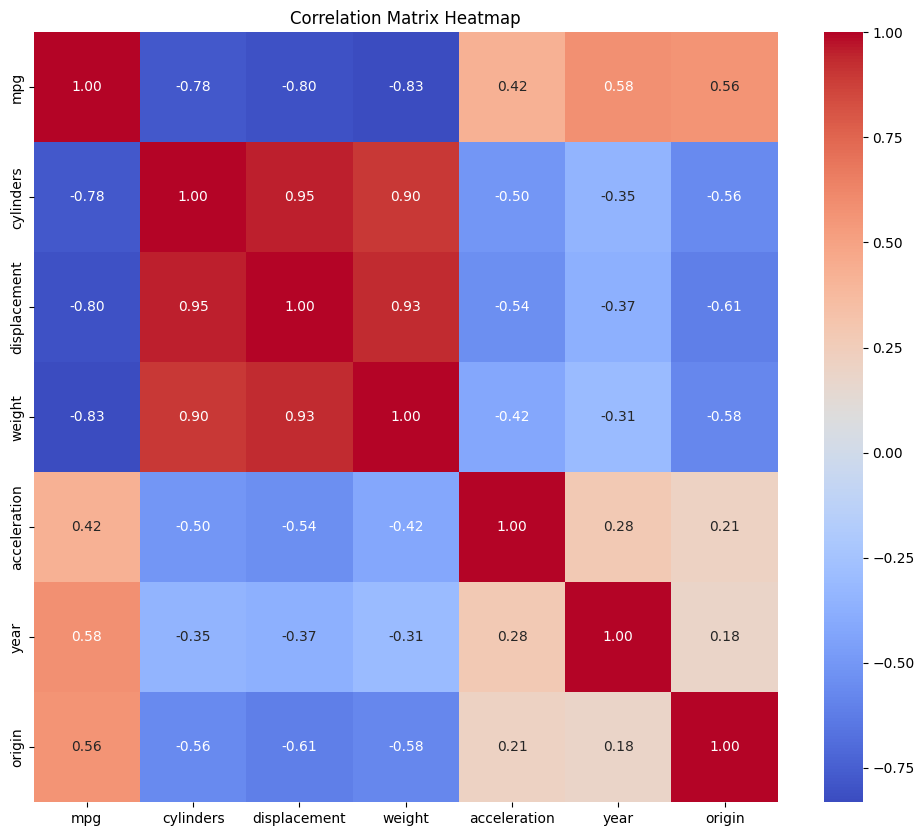

In [16]:
# (b) Compute the matrix of correlations between the variables using the DataFrame.corr() method.
# First frop the name, the non-numeric column
value_df = df.select_dtypes(include=[np.number])
corr_matrix = value_df.corr()
print(corr_matrix)

# Visualize the correlation matrix using a heatmap
ax = plt.figure(figsize=(12, 10))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')

 (c) Use the `sm.OLS()` function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the `summarize()`  function to print the results. Comment on the output. For instance:


In [24]:
# (c) Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors.
import statsmodels.api as sm
X = value_df.drop(columns=['mpg'])
y = value_df['mpg']
X = sm.add_constant(X)  # Adds a constant term to the predictor
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     298.9
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.72e-142
Time:                        21:57:06   Log-Likelihood:                -1037.7
No. Observations:                 397   AIC:                             2089.
Df Residuals:                     390   BIC:                             2117.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -20.1358      4.145     -4.858   

i. Is there a relationship between the predictors and the response? Use the `anova_lm()` function from statsmodels to answer this question.

In [26]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# 1. Recombine the data into a single DataFrame for the formula interface
# (Assuming 'df' is your original DataFrame with 'mpg' and all predictors)
# Note: You need to clean 'df' for the 'horsepower' and 'name' columns first
# Since you used value_df in your OLS:
formula_df = df.copy() 
# Ensure 'horsepower' is numeric, handle '?' if needed (assuming you handled this in your original execution)
formula_df['horsepower'] = pd.to_numeric(formula_df['horsepower'], errors='coerce')
formula_df = formula_df.dropna() # Drop rows with missing values (e.g., from 'horsepower' conversion)

# The formula string: 'response ~ predictor1 + predictor2 + ...'
predictors = ' + '.join(formula_df.columns.drop(['mpg', 'name']))
formula = f"mpg ~ {predictors}"

# 2. Fit the model using the formula interface
model_formula = smf.ols(formula=formula, data=formula_df).fit()

# Now the model object will have the 'design_info' attribute
# Print the standard summary (as you did in part c)
print(model_formula.summary())

# 3. Use anova_lm()
print('\n--- ANOVA Table using anova_lm() ---')
anova_table = anova_lm(model_formula)
print(anova_table)

# --- Interpretation for Question (c) i. ---
# To answer "Is there a relationship between the predictors and the response?"
# You must interpret the F-statistic (or Prob (F-statistic)) from the model summary.
# The ANOVA table is often used to compare nested models, but the overall F-test 
# is the key for this question.

p_value = model_formula.f_pvalue
print(f"\nProb (F-statistic) from summary: {p_value:.10f}")

# Conclusion: Since the p-value is extremely small (p < 0.05), we reject the 
# null hypothesis and conclude there is a statistically significant 
# relationship between the set of predictors and the response (mpg).

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        21:57:51   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644     -3.707   

Yes, there is a highly statistically significant relationship between the set of predictors (cylinders, displacement, horsepower, weight, acceleration, year, and origin) and the response variable ($\text{mpg}$). \
(F-statistic: $252.4$, P-value ($\text{Prob (F-statistic)}$): $2.04\text{e-}139$ (which is $0.000\dots$ or essentially zero).)

ii. Which predictors appear to have a statistically significant relationship to the response?

`displacement`, `weight`, `year` and `origin`. They all get $p$-value less than 0.05.

iii. What does the coefficient for the year variable suggest?

Coefficient of $0.7508$ means:
- Direction and Magnitude: For every one-year increase in the $\text{model year}$ of the car, the $\text{miles per gallon}$ ($\text{mpg}$) is expected to increase by $0.7508$ units, assuming all other predictors (cylinders, displacement, horsepower, weight, acceleration, and origin) are held constant.
- Statistical Significance: The P-value of $0.000$ is highly significant ($\text{P} < 0.05$). This indicates that the positive relationship between $\text{year}$ and $\text{mpg}$ is extremely unlikely to be due to random chance.

---

(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

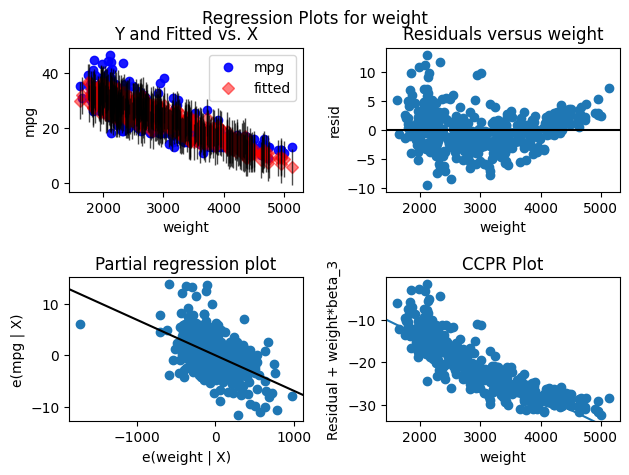

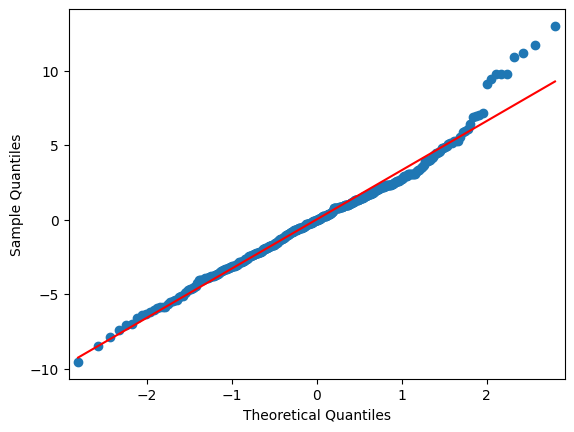

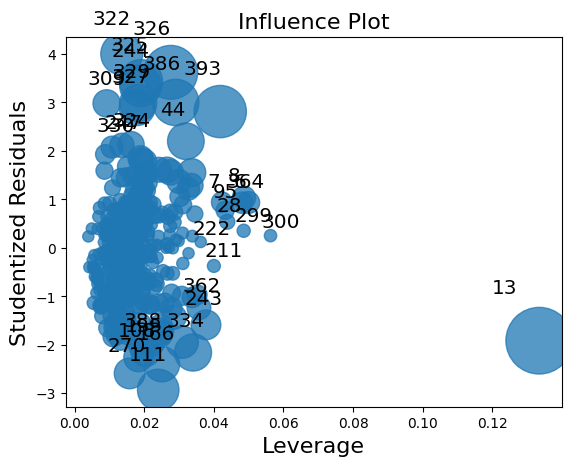

In [27]:
# (d) Plotting diagnostic plots for the linear regression fit
import statsmodels.api as sm
import matplotlib.pyplot as plt
# Residuals vs Fitted
fig = sm.graphics.plot_regress_exog(model, 'weight')
plt.show()
# Q-Q plot
sm.qqplot(model.resid, line='s')
plt.show()
# Leverage plot
sm.graphics.influence_plot(model, criterion="cooks")
plt.show()

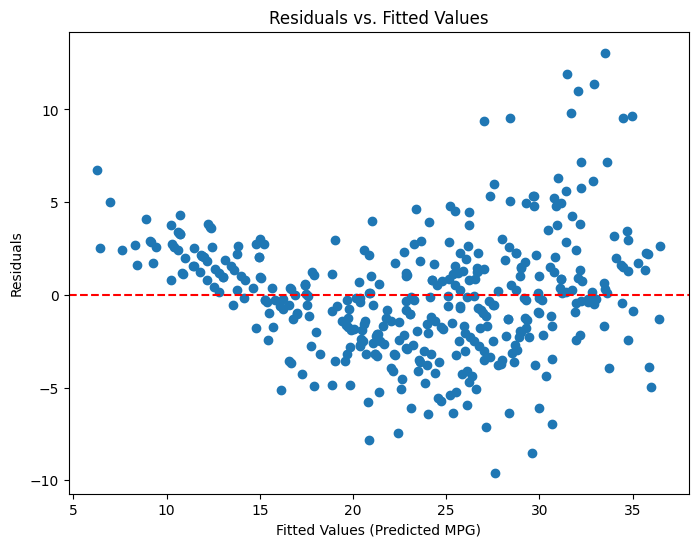

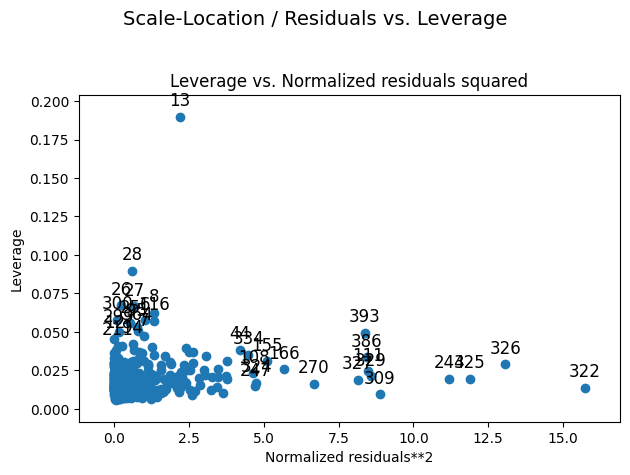

In [30]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.api import plot_leverage_resid2, influence_plot

# Assuming 'model_formula' is your fitted OLS model from sm.formula.ols().fit()

# 1. Residuals vs. Fitted Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(model_formula.fittedvalues, model_formula.resid)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values (Predicted MPG)')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Fitted Values')
plt.show()

# 3. Scale-Location (Spread-Location) Plot
fig = plot_leverage_resid2(model_formula)
fig.suptitle('Scale-Location / Residuals vs. Leverage', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust for suptitle
plt.show()

Do the residual plots suggest any unusually large outliers?\
\
Yes, the Scale-Location / Residuals vs. Leverage Plot (points far to the right) and the Influence Plot (large Studentized Residuals, Y-axis) suggest unusually large outliers.Observations 322 and 326 are the most prominent, as they have the largest Normalized Residuals Squared (X-axis values $>12$ in the Scale-Location plot) and are represented by large bubbles in the Influence Plot. This means the model significantly under- or over-predicted their $\text{mpg}$ value compared to the rest of the data.

Does the leverage plot identify any observations with unusually high leverage?\
\
Yes, the Scale-Location / Residuals vs. Leverage Plot (points far to the top) and the Influence Plot (points far to the right) identify an observation with unusually high leverage.Observation 13 stands out with the highest leverage (Y-axis value $\approx 0.190$ in the Scale-Location plot). This observation has extreme predictor values (e.g., high weight, high displacement) compared to the majority of the data.Since Observation 13 also results in the largest Cook's Distance (largest bubble in the Influence Plot), it is the most influential point in the dataset. Removing it would significantly change the estimated regression coefficients.

---

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?

In [34]:
# (e) Fit models with interactions
# Define a formula with interaction terms
interaction_formula = 'mpg ~ cylinders * displacement + horsepower * weight + acceleration * origin + year'
# Fit the model with interactions
interaction_model = smf.ols(formula=interaction_formula, data=formula_df).fit()
# Print the summary of the interaction model
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     250.3
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.13e-160
Time:                        23:36:14   Log-Likelihood:                -964.46
No. Observations:                 392   AIC:                             1951.
Df Residuals:                     381   BIC:                             1995.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 10

In [37]:
# Check for statistically significant interaction terms
significant_interactions = interaction_model.pvalues[interaction_model.pvalues < 0.05]
print("\nStatistically Significant Interaction Terms (p < 0.05):")
print(significant_interactions)


Statistically Significant Interaction Terms (p < 0.05):
Intercept              3.085494e-02
horsepower             3.228893e-12
weight                 8.227111e-20
horsepower:weight      2.064387e-09
acceleration           2.778634e-04
origin                 1.318795e-03
acceleration:origin    2.053410e-04
year                   6.151388e-51
dtype: float64


The $\text{R}^2$ of $0.868$ is a significant improvement over the $0.821$ from the main-effects-only model, indicating that the chosen interaction terms successfully capture important non-additive effects in the data.Note on Multicollinearity: The model still displays a high condition number ($\mathbf{1.34\text{e}+07}$), which is an improvement over the previous all-interactions model but still indicates strong multicollinearity. This explains why some main effects ($\text{cylinders}$, $\text{displacement}$) **are not statistically significant**, even though the overall model is very strong.

---

(f) Try a few different transformations of the variables, such as $\log X,\; \sqrt{X},\; X^2$. Comment on your findings.


In [38]:
# Create the transformed response variable
formula_df['gphm'] = 100 / formula_df['mpg']

# Fit the model
gphm_model = smf.ols(formula='gphm ~ cylinders + displacement + horsepower + weight + acceleration + year + origin', data=formula_df).fit()

print(gphm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gphm   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     423.2
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          3.45e-176
Time:                        23:45:28   Log-Likelihood:                -330.99
No. Observations:                 392   AIC:                             678.0
Df Residuals:                     384   BIC:                             709.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        9.1433      0.794     11.518   

In [39]:
# Fit the model with the quadratic weight term
# I() is used to prevent the operator (**) from being treated as a formula operator
quadratic_weight_model = smf.ols(formula='mpg ~ cylinders + displacement + horsepower + weight + I(weight**2) + acceleration + year + origin', data=formula_df).fit()

print(quadratic_weight_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     284.2
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          6.24e-156
Time:                        23:46:28   Log-Likelihood:                -981.56
No. Observations:                 392   AIC:                             1981.
Df Residuals:                     383   BIC:                             2017.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.4795      4.614      0.

Model 1 commentary: This transformation was highly effective. The reciprocal of $\text{mpg}$ (which represents fuel consumption or "gallons per 100 miles") is known to have a more linear relationship with physical attributes like engine $\text{displacement}$ and $\text{weight}$ than $\text{mpg}$ itself. This transformation simultaneously addressed the issues of non-linearity and heteroscedasticity, leading to a much better fit and a more valid OLS model.\
\
Model 2 commentary: Adding the $\mathbf{\text{weight}^2}$ term was a good partial fix. The significant jump in $R^2$ confirms that $\text{weight}$ has a non-linear (curved) relationship with $\text{mpg}$, as suggested by the diagnostic plots. However, since the $\mathbf{R^2}$ is still lower than Model 1, Model 2 only partially addressed the non-linearity in the entire dataset (which affected other variables as well), demonstrating that the response transformation (Model 1) was the superior overall solution.


Conclusion: The findings confirm that transformations are necessary and effective for this dataset:
- The Reciprocal of $\text{mpg}$ (Model 1) provides the best-fitting and most stable linear model (highest $\text{Adj. R}^2$ of $0.881$), successfully mitigating the major violations of OLS assumptions.
- The Quadratic $\text{weight}$ term (Model 2) significantly improved the fit by correcting the non-linearity of $\text{weight}$, but Model 1 is the preferred model for prediction and inference.